# Reinforcement Learning Meeting Overview

This notebook gives a short overview of the current Reinforcement Learning (RL) prototype. It focuses on the implemented dispatching-rule selection problem, the current results, and the key discussion points for the next project phase.

## 1. Goal

The RL approach does not optimize station capacities. Instead, it dynamically selects a dispatching rule when the sorting station has to choose between waiting orders. The agent can choose between FIFO, Earliest Due Date, Longest Waiting Time, and Highest Lateness Risk. The current implementation is a tabular Q-learning prototype intended to test whether adaptive dispatching can improve performance compared with fixed dispatching rules.

## 2. Decision Space

**Decision point:** the sorting server is available and the sorting queue contains at least two orders.

**Actions:**

- `0`: FIFO
- `1`: Earliest Due Date
- `2`: Longest Waiting Time
- `3`: Highest Lateness Risk

**State:**

$$
s = (q_{sorting}, q_{evaluation}, wip, due\_risk, rework)
$$

All state values are discretized into bins. The state summarizes the sorting queue, evaluation queue, total work in progress, share of near-due orders, and share of rework orders.

**Reward:** the agent receives accumulated event rewards between decision points. Completed orders are rewarded, late orders and failed evaluations are penalized, and small penalties are added for WIP and queue length.

### Q-Learning Update

The tabular Q-learning update is:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$$

Where:

- $s$: current state
- $a$: selected dispatching rule
- $r$: accumulated reward until the next decision point
- $s'$: next state
- $\alpha$: learning rate
- $\gamma$: discount factor
- $\epsilon$: exploration probability for epsilon-greedy action selection

### Reward Function

The reward is accumulated during one simulation episode:

$$
r = 10 \cdot N_{completed} - 20 \cdot N_{late} - 3 \cdot N_{eval\_failures} - 0.001 \cdot WIP - 0.002 \cdot Q_{total}
$$

The small WIP and queue penalties are applied at decision points. The reward design is therefore a key modelling choice because it defines what the RL agent is actually trying to improve.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path.cwd()
RESULTS_DIR = BASE_DIR / "rl_results_test"

with open(RESULTS_DIR / "rl_config.json", encoding="utf-8") as file:
    config = json.load(file)

baselines = pd.read_csv(RESULTS_DIR / "baselines.csv")
random_agent = pd.read_csv(RESULTS_DIR / "random_agent.csv")
q_training = pd.read_csv(RESULTS_DIR / "q_learning_training.csv")
q_eval = pd.read_csv(RESULTS_DIR / "q_learning_evaluation.csv")

baselines = baselines[baselines["error"].fillna("") == ""]
random_agent = random_agent[random_agent["error"].fillna("") == ""]
q_training = q_training[q_training["error"].fillna("") == ""]
q_eval = q_eval[q_eval["error"].fillna("") == ""]

## 3. Experiment Setup

In [2]:
setup = pd.DataFrame(
    [
        {"item": "Training episodes", "value": config["N_TRAINING_EPISODES"]},
        {"item": "Evaluation replications", "value": config["N_EVAL_REPLICATIONS"]},
        {"item": "Baseline replications per rule", "value": config["N_BASELINE_REPLICATIONS"]},
        {"item": "Random-agent replications", "value": config["N_RANDOM_REPLICATIONS"]},
        {"item": "Run duration", "value": config["RUN_DURATION"]},
        {"item": "Rate multiplier", "value": config["RATE_MULTIPLIER"]},
        {"item": "Due date lower bound", "value": config["DUE_DATE_LOWER_BOUND"]},
        {"item": "Due date upper bound", "value": config["DUE_DATE_UPPER_BOUND"]},
    ]
)
setup

,item,value
0,Training episodes,1000.0
1,Evaluation replications,30.0
2,Baseline replications per rule,30.0
3,Random-agent replications,30.0
4,Run duration,1440.0
5,Rate multiplier,0.9
6,Due date lower bound,4.0
7,Due date upper bound,8.0


In [3]:
display(pd.Series(config["STATION_CAPACITIES"], name="capacity").to_frame())
display(pd.Series(config["Q_LEARNING_CONFIG"], name="value").to_frame())

,capacity
preparation_capacity,1
sorting_capacity,1
analysis1_capacity,1
analysis2_capacity,1
evaluation_capacity,1
dispatching_capacity,1
worker_capacity,1


,value
alpha,0.100
gamma,0.950
epsilon,1.000
epsilon_decay,0.995
epsilon_min,0.050


## 4. Core Results

In [4]:
baseline_summary = (
    baselines.groupby("baseline_rule")
    .agg(
        total_reward=("total_reward", "mean"),
        late_order_fraction=("late_order_fraction", "mean"),
        time_in_system_mean=("time_in_system_mean", "mean"),
    )
    .reset_index()
    .rename(columns={"baseline_rule": "strategy"})
)

random_summary = pd.DataFrame(
    [
        {
            "strategy": "Random",
            "total_reward": random_agent["total_reward"].mean(),
            "late_order_fraction": random_agent["late_order_fraction"].mean(),
            "time_in_system_mean": random_agent["time_in_system_mean"].mean(),
        }
    ]
)

q_summary = pd.DataFrame(
    [
        {
            "strategy": "Q-learning",
            "total_reward": q_eval["total_reward"].mean(),
            "late_order_fraction": q_eval["late_order_fraction"].mean(),
            "time_in_system_mean": q_eval["time_in_system_mean"].mean(),
        }
    ]
)

strategy_summary = pd.concat([baseline_summary, random_summary, q_summary], ignore_index=True)
strategy_summary.sort_values("total_reward", ascending=False).round(3)

,strategy,total_reward,late_order_fraction,time_in_system_mean
5,Q-learning,144.167,0.459,344.325
1,FIFO,109.500,0.465,343.372
3,Longest Waiting Time,109.500,0.465,343.372
0,EDD,27.500,0.479,347.437
4,Random,-27.833,0.489,350.190
2,Highest Lateness Risk,-151.167,0.511,345.773


Comparison with absoulte min time in system.

## 5. Visualizations

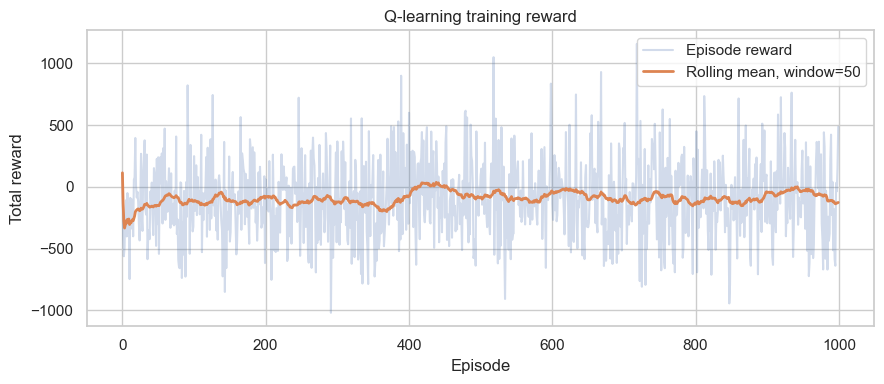

In [5]:
training_plot = q_training[["episode", "total_reward"]].copy()
training_plot["reward_smoothed"] = training_plot["total_reward"].rolling(50, min_periods=1).mean()

plt.figure(figsize=(9, 4))
plt.plot(training_plot["episode"], training_plot["total_reward"], alpha=0.25, label="Episode reward")
plt.plot(training_plot["episode"], training_plot["reward_smoothed"], linewidth=2, label="Rolling mean, window=50")
plt.title("Q-learning training reward")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.tight_layout()

- More episodes (maybe 10000)
- Highlight best reward like in BO.
- BO for hyperparameter tunning of q-learning (alpha, gamma, epsilon).

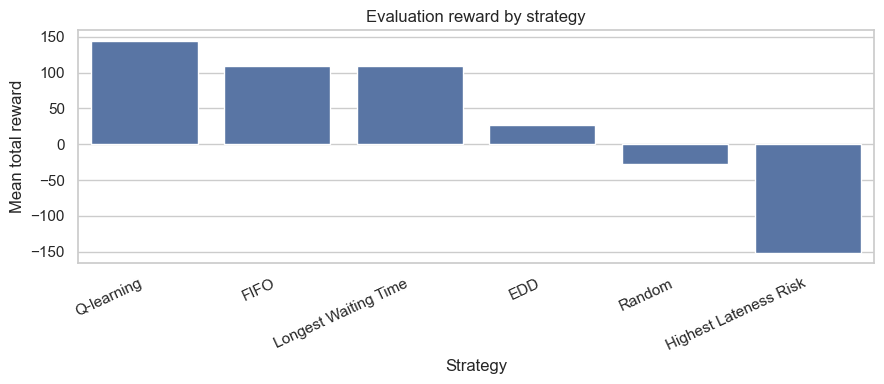

In [6]:
plot_order = strategy_summary.sort_values("total_reward", ascending=False)["strategy"]

plt.figure(figsize=(9, 4))
sns.barplot(data=strategy_summary, x="strategy", y="total_reward", order=plot_order)
plt.title("Evaluation reward by strategy")
plt.xlabel("Strategy")
plt.ylabel("Mean total reward")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

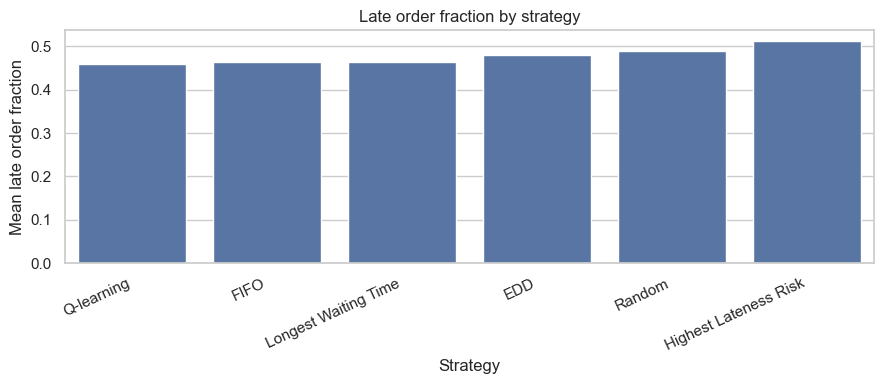

In [7]:
plt.figure(figsize=(9, 4))
sns.barplot(data=strategy_summary, x="strategy", y="late_order_fraction", order=plot_order)
plt.title("Late order fraction by strategy")
plt.xlabel("Strategy")
plt.ylabel("Mean late order fraction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

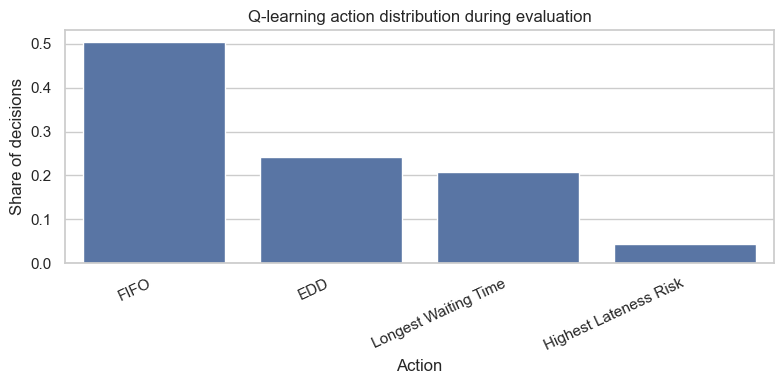

In [8]:
action_names = {
    "action_0_count": "FIFO",
    "action_1_count": "EDD",
    "action_2_count": "Longest Waiting Time",
    "action_3_count": "Highest Lateness Risk",
}
action_distribution = q_eval[list(action_names)].sum().rename(index=action_names)
action_distribution = (action_distribution / action_distribution.sum()).reset_index()
action_distribution.columns = ["action", "share"]

plt.figure(figsize=(8, 4))
sns.barplot(data=action_distribution, x="action", y="share")
plt.title("Q-learning action distribution during evaluation")
plt.xlabel("Action")
plt.ylabel("Share of decisions")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

## 6. Interpretation

- Q-learning currently achieves the highest mean reward among the evaluated strategies.
- The late order fraction remains high for all strategies, so the current RL setup does not solve the lateness problem.
- The fixed Longest Waiting Time rule is a strong baseline and should remain in the final comparison.
- The Q-table is small, which suggests that the discretized state space is compact and interpretable, but may also limit policy quality.
- The reward function is central: it may reward throughput enough to improve total reward while still allowing many late orders.
- RL should currently be presented as an exploratory dispatching prototype unless further improvements are made.

## 7. Discussion Points

- Should RL be improved further or presented as a proof of concept?
- Is dynamic dispatching-rule selection a suitable RL problem for this thesis scope?
- Are the current baselines sufficient, especially FIFO, EDD, Longest Waiting Time, Highest Lateness Risk, and Random?
- Should we consider a more complex RL algorithm (e.g., DQN) or a more compact state representation to improve learning?
- Should we experiment with different reward function designs to better align with the service-level objectives?
- Dispatching Rules: Are EDD and Highest Lateness Risk too similar, and should we consider a different rule (e.g., Shortest Processing Time) to increase the action space diversity?
- Is the current performance good enough to include RL as a secondary approach?
- Should the reward function penalize lateness more strongly or use a clearer service-level objective?

## Discussion/TODO

- Dispatching Rules: EDD and Highest Lateness Risk too similar, and should we consider a different rule (e.g., Shortest Processing Time) to increase the action space diversity
- Same seeds for comparison of baseline and RL.
- Optional: Maybe multiple runs with 30 trials of RL with different seeds to show stability of learning.